# CPPI: the floor, the cushion, and the gap

## Goal

Implement a discrete cushion rule and test a path on which it fails to maintain the floor. With the same terminal risky-asset price, immediate CPPI ends at **100.26 after gradual losses** and **75.57 after a discrete gap**, against a terminal floor of 80. Those outcomes belong to the declared constructed paths; they do not measure protection probabilities.

[Detailed strategy design](README.md) · [All allocation ideas](../../README.md)

## Setup and assumptions

Initial wealth 100; terminal nominal objective 80 after 80 periods; multiplier three; risky exposure capped at 100%; cash earns a hypothetical 3% effective annual rate. Each risky purchase or sale costs 5 basis points. Daily decisions use pre-fee wealth, target a fraction of post-fee wealth and earn the next period's return. We also expose one extra complete-period execution delay. No terminal liquidation, cash-transfer fee, guarantee, option or external funding is assumed.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "research/dynamic_exposure.py").exists())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
from research.dynamic_exposure import volatility_targets, run_exposure, run_cppi
from research.common import performance
plt.rcParams.update({"figure.figsize": (10, 6), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.18})
BLUE, GOLD, GREY, OLIVE = "#22577a", "#bc6c25", "#555555", "#758e4f"
cash_rate = 1.03 ** (1 / 252) - 1  # hypothetical constant 3% effective annual cash rate

## 1. Build two paths with an identical terminal risky price

Both paths start with twenty +0.1% returns. One then falls 40% over twenty periods; the other loses 40% in a single gap and remains flat. Both recover by the same factor over the final forty periods. This keeps the endpoint fixed while changing the sequence of trading opportunities. These are original deterministic illustrations, not historical price records.

At decision time, $F_t=80/(1+r_c)^{80-t}$ and $w_t=\min(1,3\max(V_t-F_t,0)/V_t)$. The floor rolls forward with the same cash return used in portfolio accounting. Immediate execution means a decision established before return $t$ owns that return; it never observes the return first. An extra delay queues the weight for one full period, starting from cash.

In [2]:
gradual = np.r_[np.full(20, 0.001), np.full(20, 0.60 ** (1 / 20) - 1),
                np.full(40, (1 / 0.60) ** (1 / 40) - 1)]
gap = np.r_[np.full(20, 0.001), -0.40, np.zeros(19),
            np.full(40, (1 / 0.60) ** (1 / 40) - 1)]
returns_by_path = {"Gradual": gradual, "Gap": gap}
period = np.arange(1, 81)
np.testing.assert_allclose(np.prod(1 + gradual), np.prod(1 + gap))
cppi = {(name, delay): run_cppi(returns, cash_rate=cash_rate, delay=delay)
        for name, returns in returns_by_path.items() for delay in [0, 1]}
fixed = {name: run_exposure(returns, np.full(80, 0.60), cash_rate=cash_rate)
         for name, returns in returns_by_path.items()}

## 2. Review floor gaps, costs and turnover together

The floor is a reference funding level. A negative gap means wealth is below the cash value required to meet the objective. The fixed allocation uses the same reference for comparison but never attempts to defend it. Summed turnover is absolute risky dollars traded divided by each period's pretrade wealth, not a count of target-weight changes.

In [3]:
rows = []
for (name, delay), path in cppi.items():
    rows.append({"Path / policy": f"{name}: CPPI, delay {delay}",
                 "Terminal wealth": path.wealth_end.iloc[-1],
                 "Minimum floor gap": path.floor_gap.min(),
                 "Risky turnover (x)": path.turnover.sum(), "Fees per initial 100": path.fee.sum()})
for name, path in fixed.items():
    floor = cppi[(name, 0)].floor_end
    rows.append({"Path / policy": f"{name}: fixed 60%", "Terminal wealth": path.wealth_end.iloc[-1],
                 "Minimum floor gap": (path.wealth_end - floor).min(),
                 "Risky turnover (x)": path.turnover.sum(), "Fees per initial 100": path.fee.sum()})
display(pd.DataFrame(rows).set_index("Path / policy").round(3))

,Terminal wealth,Minimum floor gap,Risky turnover (x),Fees per initial 100
Path / policy,,,,
"Gradual: CPPI, delay 0",100.263,4.509,1.348,0.065
"Gradual: CPPI, delay 1",97.120,3.978,1.314,0.063
"Gap: CPPI, delay 0",75.566,-4.434,1.169,0.052
"Gap: CPPI, delay 1",75.618,-4.382,1.413,0.061
Gradual: fixed 60%,101.783,-4.904,0.846,0.041
Gap: fixed 60%,104.934,-2.591,0.849,0.040


## 3. An identical market endpoint does not imply an identical CPPI outcome

The top panel confirms that both risky paths recover to the same endpoint. Below, gradual trading reduces risky exposure before the full decline has accumulated. A jump crosses the floor before the strategy can act. The dashed delayed paths implement exactly the queued policy: after a breach, one stale risky order can still execute. Delay need not make every realized path worse, so both outcomes are retained without selecting a preferred convention.

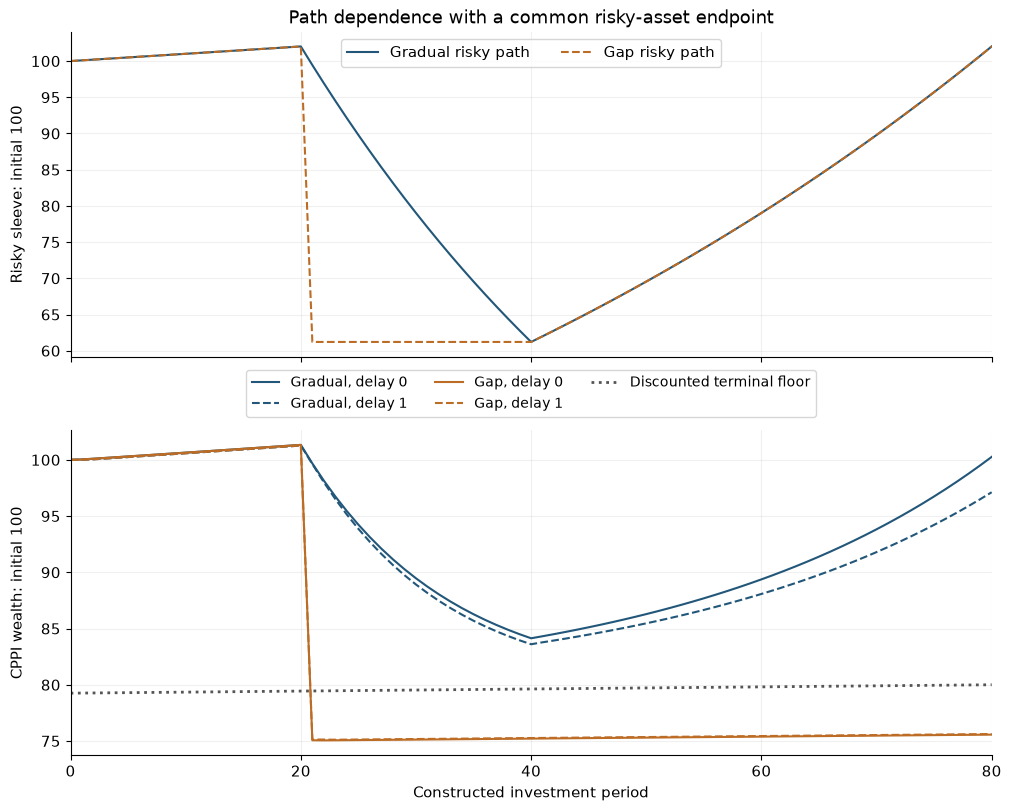

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, layout="constrained")
for name, returns in returns_by_path.items():
    axes[0].plot(np.r_[0, period], 100 * np.r_[1, np.cumprod(1 + returns)],
                 color=BLUE if name == "Gradual" else GOLD,
                 linestyle="-" if name == "Gradual" else "--", label=f"{name} risky path")
for (name, delay), path in cppi.items():
    axes[1].plot(np.r_[0, period], np.r_[100, path.wealth_end],
                 color=BLUE if name == "Gradual" else GOLD,
                 linestyle="-" if delay == 0 else "--", label=f"{name}, delay {delay}")
floor = cppi[("Gap", 0)]
axes[1].plot(np.r_[0, period], np.r_[floor.floor_start.iloc[0], floor.floor_end],
             color=GREY, linestyle=":", linewidth=2, label="Discounted terminal floor")
axes[0].set(ylabel="Risky sleeve: initial 100", title="Path dependence with a common risky-asset endpoint")
axes[1].set(ylabel="CPPI wealth: initial 100", xlabel="Constructed investment period")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=2)
axes[1].legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3, fontsize=10)
axes[1].set_xlim(0, 80)
axes[1].set_xticks([0, 20, 40, 60, 80])
plt.show()

## 4. Inspect what happens after the cushion is exhausted

A fresh CPPI decision is zero-risk when wealth is below its floor. Cash thereafter grows at the funding rate, so the deficit is not repaired by a recovery of the risky sleeve. The delayed version demonstrates why a decision and an execution must be recorded separately. The extra risky period appears between the two vertical exposure reductions before the delayed policy reaches cash.

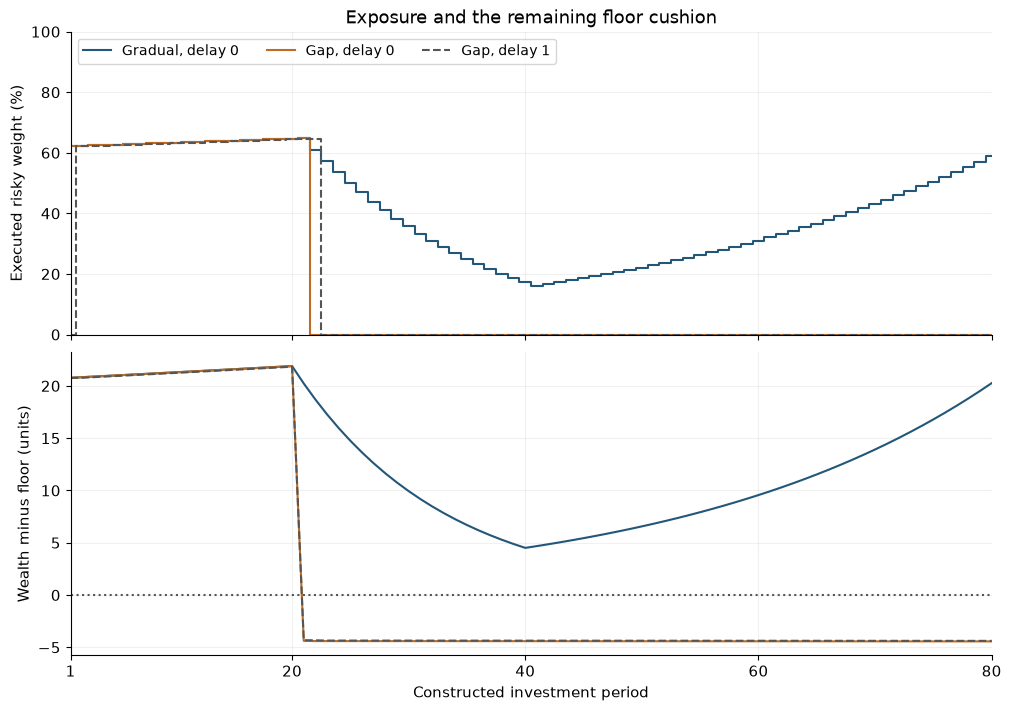

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, layout="constrained")
styles = [("Gradual", 0, BLUE, "-"), ("Gap", 0, GOLD, "-"), ("Gap", 1, GREY, "--")]
for name, delay, color, style in styles:
    path = cppi[(name, delay)]
    label = f"{name}, delay {delay}"
    axes[0].step(period, 100 * path.target_risky, where="mid", color=color, linestyle=style, label=label)
    axes[1].plot(period, path.floor_gap, color=color, linestyle=style, label=label)
axes[0].set(ylabel="Executed risky weight (%)", ylim=(0, 100), title="Exposure and the remaining floor cushion")
axes[0].legend(loc="upper left", ncol=3, fontsize=10)
axes[1].axhline(0, color=GREY, linestyle=":")
axes[1].set(ylabel="Wealth minus floor (units)", xlabel="Constructed investment period")
axes[1].set_xlim(1, 80)
axes[1].set_xticks([1, 20, 40, 60, 80])
plt.show()

## 5. Verify the mechanism independently

With zero cash return and fees, initial wealth 100 and floor 80 create a cushion of 20. A multiplier of three puts 60 in the risky sleeve and 40 in cash. A 40% risky loss leaves $60(0.60)+40=76$, breaching the floor by four. The familiar $1/m$ jump threshold follows from this simplified, uncapped, immediate, costless case. It is not an exact threshold for every policy above.

The zero-cushion example sets a terminal objective equal to the future value of initial cash. Portfolio wealth and the floor should then grow together with no risky allocation. The timing check changes the already queued return but cannot change the weight owning that return or the next delayed target.

In [6]:
known = run_cppi([-0.40, 0.10], terminal_floor=80, multiplier=3, cost_bps=0)
np.testing.assert_allclose(known.wealth_end, [60 * 0.60 + 40, 76])
np.testing.assert_allclose(known.target_risky, [0.60, 0])
funded = run_cppi([0.20, -0.20, 0.30], terminal_floor=100 * 1.01 ** 3,
                  cash_rate=0.01, cost_bps=0)
np.testing.assert_allclose(funded.target_risky, 0, atol=1e-14)
np.testing.assert_allclose(funded.wealth_end, funded.floor_end)
base = run_cppi([0.0, -0.40, 0.10, 0.10], delay=1, cost_bps=0)
changed = run_cppi([0.0, 0.40, 0.10, 0.10], delay=1, cost_bps=0)
np.testing.assert_array_equal(base.target_risky.iloc[:3], changed.target_risky.iloc[:3])
for path in cppi.values():
    np.testing.assert_allclose(path.floor_end, path.floor_start * (1 + cash_rate))
    np.testing.assert_allclose(path.risky_after_trade + path.cash_after_trade + path.fee, path.wealth_start)
assert cppi[("Gradual", 0)].floor_gap.min() > 0
assert cppi[("Gap", 0)].floor_gap.min() < 0
print("Passed: analytic gap loss, zero-cushion funding, delayed ownership, floor growth, dollar reconciliation.")

Passed: analytic gap loss, zero-cushion funding, delayed ownership, floor growth, dollar reconciliation.


## Takeaways and next questions

CPPI makes risky exposure depend on the cushion. The declared gradual-loss path stays above its floor, while the equally specified gap path breaches it and misses the recovery. Calling the floor a target is consistent with this finite-step implementation; calling it guaranteed capital protection would not be.

A useful next experiment retains a declared grid of gap sizes, multipliers, trading intervals, costs and delays, and separates a predetermined terminal floor from drawdown-based ratchets. Risk in the cash instrument and failure to trade during stress are additional assumptions to examine rather than silently treating the safe sleeve as infallible.

[Perold and Sharpe's primary article](https://rpc.cfainstitute.org/research/financial-analysts-journal/1988/dynamic-strategies-for-asset-allocation) provides the dynamic allocation framework. The scenarios, finite-horizon cash floor and dollar ledger here are original. [Volatility targeting](../17-volatility-targeting/README.md) applies a different signal to the same self-financing accounting.